In [3]:
import pandas as pd
import numpy as np
import glob
import os
import sys
import talib
import pandas_ta as pa_ta
import yfinance
import matplotlib.pyplot as plt
import yfinance as yf
print(yf.__version__)

sys.path.append(os.path.dirname(os.path.realpath('__file__')) + '/../../')
from src.common.constants import *
from MomentumLearning import Utils

# granularities = ['5m', '15m', '30m', '1h']
granularities = [('1m', '7d')]
for granularity in granularities:
    df = Utils.read_Historical_Data_From_Yf_with_period('HKDINR=X', granularity[1], granularity[0])
    df.dropna(inplace=True)
    df.to_csv(f'hkd_inr_{granularity[1]}_{granularity[0]}.csv')



# ticker = yf.Ticker("QQQ")  # S&P 500 index options
# option_chain = ticker.option_chain()
# print(option_chain)




0.2.59


In [5]:
import yfinance as yf

def classify_stocks_to_sector(self, symbols_list):
    equityNameToSectorDict = {}
    for symbol in symbols_list:
        stock = yf.Ticker(symbol + ".NS")
        info = stock.info
        sector = info.get('sector', 'Unknown')
        equityNameToSectorDict[symbol] = sector
    return equityNameToSectorDict

# Example usage
symbols = ["RELIANCE", "TCS", "HDFCBANK"]
sector_dict = classify_stocks_to_sector(None, symbols)
print(sector_dict)

{'RELIANCE': 'Energy', 'TCS': 'Technology', 'HDFCBANK': 'Financial Services'}


In [4]:
df.to_csv('/home/qa/runtime/data/analysis_out/garch/spy_1d_10y.csv', index=True)

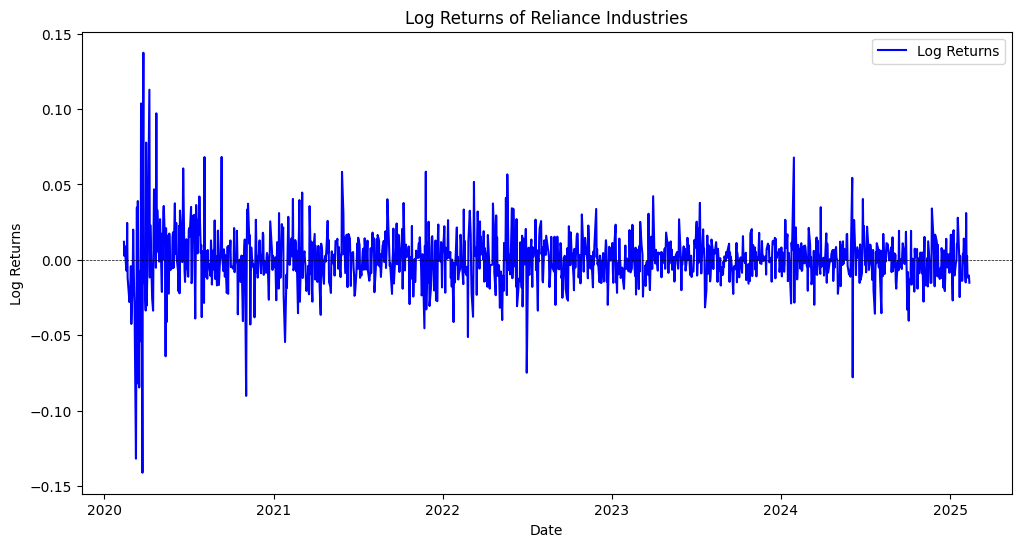

In [ ]:
# df.to_csv('/home/qa/runtime/data/analysis_out/reliance.csv', index=True)

df = pd.read_csv('/home/qa/runtime/data/analysis_out/reliance.csv')
# Convert Date column and sort
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Compute Log Returns
df["Log_Returns"] = np.log(df["Close"] / df["Close"].shift(1))
df = df.dropna()

# Plot Log Returns
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Log_Returns"], label="Log Returns", color="blue")
plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.title("Log Returns of Reliance Industries")
plt.xlabel("Date")
plt.ylabel("Log Returns")
plt.legend()
plt.show()


In [18]:
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller (ADF) test on log returns
adf_result = adfuller(df["Log_Returns"])

# Extract the test statistic and p-value
adf_statistic = adf_result[0]
p_value = adf_result[1]

# Determine stationarity
is_stationary = p_value < 0.05

# Display results
{
    "ADF Test Statistic": adf_statistic,
    "p-value": p_value,
    "Stationary": is_stationary
}


{'ADF Test Statistic': -10.23512493945678,
 'p-value': 4.9120542846943274e-18,
 'Stationary': True}

/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


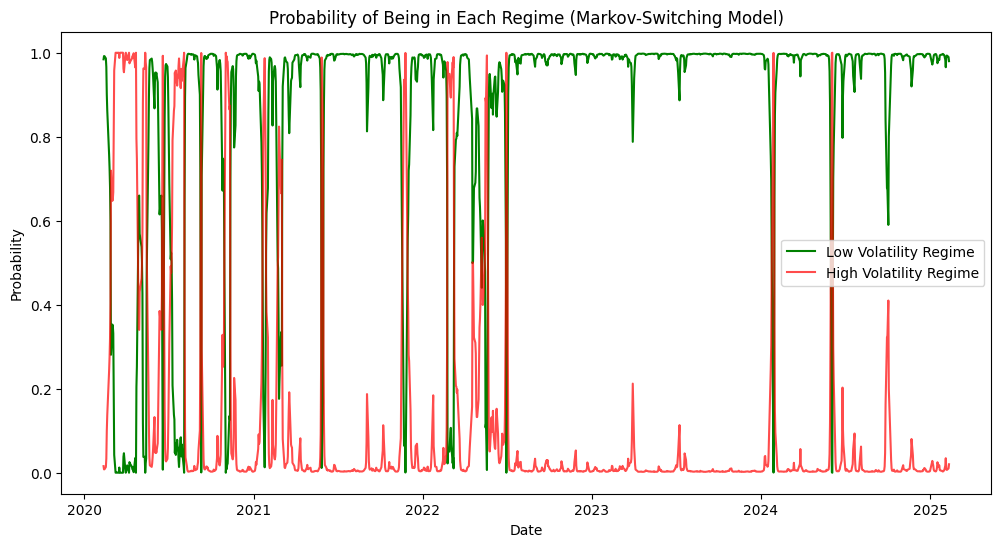

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from arch.univariate import GARCH

# Fit Markov-Switching Model
ms_model = MarkovRegression(df["Log_Returns"], k_regimes=2, trend="c", switching_variance=True)
ms_fit = ms_model.fit()

# Extract Smoothed Probabilities
df["Regime_1_Prob"] = ms_fit.smoothed_marginal_probabilities[0]
df["Regime_2_Prob"] = ms_fit.smoothed_marginal_probabilities[1]

# Plot Regime Probabilities
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["Date"], df["Regime_1_Prob"], label="Low Volatility Regime", color="green")
ax.plot(df["Date"], df["Regime_2_Prob"], label="High Volatility Regime", color="red", alpha=0.7)
ax.set_title("Probability of Being in Each Regime (Markov-Switching Model)")
ax.set_xlabel("Date")
ax.set_ylabel("Probability")
ax.legend()
plt.show()

/home/qa/runtime/.venv/lib/python3.10/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003478. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


Iteration:      1,   Func. Count:      7,   Neg. LLF: 7.538960159871749e+18
Iteration:      2,   Func. Count:     20,   Neg. LLF: 347601167748104.7
Iteration:      3,   Func. Count:     33,   Neg. LLF: 325473044.96450245
Iteration:      4,   Func. Count:     47,   Neg. LLF: -3354.873250626559
Optimization terminated successfully    (Exit mode 0)
            Current function value: -3354.87325297432
            Iterations: 8
            Function evaluations: 47
            Gradient evaluations: 4


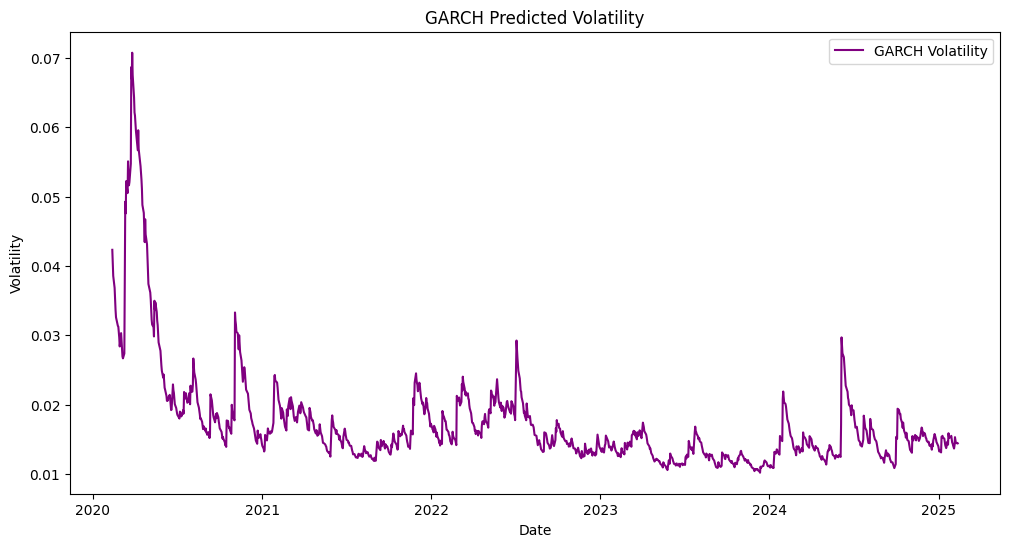

In [19]:
from arch.univariate import ConstantMean

# Define a Constant Mean Model with GARCH(1,1)
garch = ConstantMean(df["Log_Returns"])
garch.volatility = GARCH(1, 1)
garch_fit = garch.fit()

# Predict Conditional Volatility
df["GARCH_Volatility"] = garch_fit.conditional_volatility

# Plot Volatility
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["GARCH_Volatility"], label="GARCH Volatility", color="purple")
plt.title("GARCH Predicted Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

